<div style=" background-color: #439cc8;border-radius: 8px;font-size:2.5rem;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">NOTEBOOK 1</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">EDA données Autoscout24
</h2>
</div>

<div id="ch1" style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2  style="margin: auto; padding: 20px; color:#fff; ">1 - Import des modules et acquisition des données</h2>
</div>

<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    💡 Note : Sur Jupyter le sommaire est disponible dans le menu en sélectionnant View puis Table of Contents
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.1 - Adresse des données</h3>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Adresse des données : https://www.kaggle.com/datasets/wspirat/germany-used-cars-dataset-2023
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.2 - Chargement</h3>
</div>

<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.2.1 - Import des librairies</h4>
</div>

In [3]:
# Import des bibliothèques de traitement des données
import pandas as pd
import numpy as np
import duckdb
import polars as pl

# Import des bibliothèques de visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Import des bibliothèques de machine learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Import des bibliothèques statistiques
from scipy.stats import chi2_contingency, anderson, kruskal, f_oneway

# Import des bibliothèques utilitaires
import os
from collections import Counter
import re

# Options pour afficher toutes les colonnes des DataFrames
pd.set_option("display.max_columns", 999)



<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.2.2 - Import des données</h4>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Indiquer le chemin où se trouve le fichier data.csv
</div>

In [4]:
# Chargement des données
my_path = r"C:/ENI/UsedCarPricePredictor_V2" # A modifier
data_path = os.path.join(my_path,"data/raw/data.csv")
raw = pd.read_csv(data_path, low_memory=False, sep=",")

raw.head()

,Unnamed: 0,brand,model,color,registration_date,year,price_in_euro,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,offer_description
0,0,alfa-romeo,Alfa Romeo GTV,red,10/1995,1995,1300,148,201,Manual,Petrol,"10,9 l/100 km",260 g/km,160500.0,2.0 V6 TB
1,1,alfa-romeo,Alfa Romeo 164,black,02/1995,1995,24900,191,260,Manual,Petrol,NaN,- (g/km),190000.0,"Q4 Allrad, 3.2L GTA"
2,2,alfa-romeo,Alfa Romeo Spider,black,02/1995,1995,5900,110,150,Unknown,Petrol,NaN,- (g/km),129000.0,ALFA ROME 916
3,3,alfa-romeo,Alfa Romeo Spider,black,07/1995,1995,4900,110,150,Manual,Petrol,"9,5 l/100 km",225 g/km,189500.0,2.0 16V Twin Spark L
4,4,alfa-romeo,Alfa Romeo 164,red,11/1996,1996,17950,132,179,Manual,Petrol,"7,2 l/100 km",- (g/km),96127.0,"3.0i Super V6, absoluter Topzustand !"


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.2.3 - Petites corrections</h4>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    La première variable est un index incrémentiel qui peut être immédiatement supprimé
</div>

In [5]:
raw = raw.drop(["Unnamed: 0"],axis=1)

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Ensuite, nous renommerons la variable offer_description en version pour des raisons de commodités
</div>


In [6]:
raw = raw.rename(columns={'offer_description': 'version'})

<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">2 - Nettoyage</h2>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.1 - Contrôle général de la qualité des données</h3>
</div>

In [7]:
raw.shape

(251079, 14)

In [8]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 251079 entries, 0 to 251078
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     251079 non-null  str    
 1   model                     251079 non-null  str    
 2   color                     250913 non-null  str    
 3   registration_date         251075 non-null  str    
 4   year                      251079 non-null  str    
 5   price_in_euro             251079 non-null  str    
 6   power_kw                  250945 non-null  str    
 7   power_ps                  250950 non-null  str    
 8   transmission_type         251079 non-null  str    
 9   fuel_type                 251079 non-null  str    
 10  fuel_consumption_l_100km  224206 non-null  str    
 11  fuel_consumption_g_km     251079 non-null  str    
 12  mileage_in_km             250927 non-null  float64
 13  version                   251078 non-null  str    
dtyp

In [9]:
# Nombre total de cellules (lignes * colonnes)
total_cells = raw.shape[0] * raw.shape[1]

# Nombre de cellules non nulles
non_null_cells = raw.count().sum()

# Taux global moyen de remplissage (en pourcentage)
taux_remplissage = (non_null_cells / total_cells) * 100

print(f"Le taux global moyen de remplissage est de {taux_remplissage:.2f}%")


Le taux global moyen de remplissage est de 99.22%


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    ✔ Excellente qualité de remplissage (99.22%)
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.2 - Suppression des observations qui n'ont pas de prix numérique</h3>
</div>

In [10]:
raw["price"] = pd.to_numeric(raw["price_in_euro"], errors="coerce")
non_num_price = raw[raw["price"].isna() & raw["price_in_euro"].notna()]
non_num_price.shape


(199, 15)

<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>⛔ Nous disposons de 199 observations ne possédant pas un prix numérique. </p>
    <p>Ces observations vont être supprimées ainsi que l’ancienne variable price_in_euro</p>
</div>

In [11]:
raw = raw.drop(list(non_num_price.index),axis=0)
raw = raw.drop(["price_in_euro"],axis=1)

In [12]:
raw.shape

(250880, 14)

In [13]:
raw.info()

<class 'pandas.DataFrame'>
Index: 250880 entries, 0 to 251078
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     250880 non-null  str    
 1   model                     250880 non-null  str    
 2   color                     250714 non-null  str    
 3   registration_date         250880 non-null  str    
 4   year                      250880 non-null  str    
 5   power_kw                  250752 non-null  str    
 6   power_ps                  250752 non-null  str    
 7   transmission_type         250880 non-null  str    
 8   fuel_type                 250880 non-null  str    
 9   fuel_consumption_l_100km  224007 non-null  str    
 10  fuel_consumption_g_km     250880 non-null  str    
 11  mileage_in_km             250818 non-null  float64
 12  version                   250880 non-null  str    
 13  price                     250880 non-null  float64
dtypes: f

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.3 - Exploration des variables</h3>
</div>

<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.3.1 - Les variables power</h4>
</div>

In [14]:
missing_pow1 = raw[raw["power_ps"].isna() & raw["power_kw"].notna()]
print(missing_pow1)


Empty DataFrame
Columns: [brand, model, color, registration_date, year, power_kw, power_ps, transmission_type, fuel_type, fuel_consumption_l_100km, fuel_consumption_g_km, mileage_in_km, version, price]
Index: []


In [15]:
display(raw[raw["power_ps"].isna()].head())

,brand,model,color,registration_date,year,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price
1396,alfa-romeo,Alfa Romeo Tonale,black,01/2023,2023,NaN,NaN,Automatic,Petrol,"5,9 l/100 km",134 g/km,15.0,SUPER 1.5 T 130PS 48-Hybrid 15KW,29970.0
1417,alfa-romeo,Alfa Romeo Tonale,black,01/2023,2023,NaN,NaN,Automatic,Hybrid,"5,9 l/100 km",134 g/km,5.0,SUPER 1.5 T 130PS 48-Hybrid 15KW,29970.0
1961,audi,Audi TT,silver,07/2001,2001,NaN,NaN,Manual,Other,NaN,- (g/km),154920.0,Roadster 1.8T quattro Mokassin-Naht,13900.0
19299,audi,Audi RS6,silver,06/2020,2020,NaN,NaN,Automatic,Petrol,"11,7 l/100 km",268 g/km,29874.0,Avant 4.0 TFSI quat/1064ps*/HGP/Keramik/VOLL,194999.0
20371,audi,Audi A6,silver,03/2021,2021,NaN,NaN,Automatic,Diesel,"4,9 l/100 km",128 g/km,74373.0,Avant design 40 TDI Aut quatt CAM AHK LED,34880.0


In [16]:
missing_pow2 = raw[raw["power_kw"].isna() & raw["power_ps"].notna()]
missing_pow2


,brand,model,color,registration_date,year,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 power_ps et power_kw ont le même niveau de complétion</p>
    <p>❌ Suppression de la variable power_kw qui est redondante</p>
</div>

In [17]:
raw = raw.drop(["power_kw"], axis=1)
raw["power_ps"] = pd.to_numeric(raw["power_ps"], errors="coerce")


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.3.2 - Les variables fuel_consumption</h4>
</div>

In [18]:
missing_cons1 = raw[
    raw["fuel_consumption_l_100km"].isna() & raw["fuel_consumption_g_km"].notna()
]
missing_cons1.head(20)


,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price
1,alfa-romeo,Alfa Romeo 164,black,02/1995,1995,260.0,Manual,Petrol,NaN,- (g/km),190000.0,"Q4 Allrad, 3.2L GTA",24900.0
2,alfa-romeo,Alfa Romeo Spider,black,02/1995,1995,150.0,Unknown,Petrol,NaN,- (g/km),129000.0,ALFA ROME 916,5900.0
18,alfa-romeo,Alfa Romeo GTV,red,03/1997,1997,201.0,Manual,Petrol,NaN,- (g/km),168791.0,2.0 V6 TB - Leder - 2.Hand,9980.0
22,alfa-romeo,Alfa Romeo Spider,black,07/1997,1997,192.0,Manual,Petrol,NaN,- (g/km),194000.0,"3,0 V6 12V",10500.0
27,alfa-romeo,Alfa Romeo,black,09/1997,1997,207.0,Manual,Petrol,NaN,- (g/km),72260.0,RZ Zagato Spider | NR.172 | SAMMLER | IL MOSTRO,99900.0
41,alfa-romeo,Alfa Romeo Spider,red,05/1999,1999,106.0,Manual,Petrol,NaN,- (g/km),114000.0,Spider 1.8 Cabrio,3490.0
43,alfa-romeo,Alfa Romeo Spider,black,01/1999,1999,192.0,Manual,Petrol,NaN,- (g/km),193000.0,"3,0 V 6 12V",10900.0
57,alfa-romeo,Alfa Romeo 145,red,01/2000,2000,120.0,Manual,Petrol,NaN,- (g/km),128000.0,*Klima*El. Fenster*Alufelgen*Lederlenkr*,3480.0
76,alfa-romeo,Alfa Romeo 156,silver,07/2001,2001,150.0,Manual,Petrol,NaN,- (g/km),119079.0,2.0 TS 16V Limousine*Alufegen*,1350.0
85,alfa-romeo,Alfa Romeo 156,black,03/2002,2002,167.0,Manual,Diesel,NaN,- (g/km),148648.0,2.4 JTD,1490.0


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 26873 observations où fuel_consumption_g_km est complétée et fuel_consumption_l_100km ne l'est pas.</p>

</div>

In [19]:
missing_cons2 = raw[
    raw["fuel_consumption_g_km"].isna() & raw["fuel_consumption_l_100km"].notna()
]

missing_cons2

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Pas de cas où fuel_consumption_g_km est vide et fuel_consumption_l_100km ne l’est pas</p>

</div>

In [20]:
import duckdb

# Comptage des occurrences de "Reichweite"
count_reichweite = duckdb.sql("""
    SELECT
      count_if(fuel_consumption_l_100km LIKE '%Reichweite%')
    + count_if(fuel_consumption_g_km LIKE '%Reichweite%')
    FROM raw
""").fetchone()[0]

print(count_reichweite)

4324


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 4324 observations contiennent la mention Reichweite qui est un mot allemand signifiant rayon d'action en français.</p>

</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.3.3 - La variable fuel-type</h4>
</div>

In [21]:
raw.fuel_type.value_counts()

fuel_type
Petrol           143280
Diesel            86421
Hybrid            12607
Electric           5967
LPG                1255
CNG                 508
Diesel Hybrid       476
Other               178
Unknown              96
Hydrogen             82
Ethanol              10
Name: count, dtype: int64

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.4 - Corrections</h3>
</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.4.1 - Attribution de 0 g/km lorsque la voiture est électrique</h4>
</div>

In [22]:
# Nous pouvons maintenant écrire 0 g/km lorsqu'il s'agit d'un véhicule électrique
raw.loc[raw["fuel_type"] == "Electric", "fuel_consumption_g_km"] = "0 g/km"


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.4.2 - fuel_consumption_g_km = manquant si le modèle est hybride et que fuel_consumption_g_km contient Reichweite</h4>
</div>

In [23]:
# Mise à jour de la colonne 'fuel_consumption_g_km' pour les véhicules hybrides contenant "Reichweite"
raw.loc[
    (raw["fuel_type"].str.contains("Hybrid", na=False, regex=False))
    & (raw["fuel_consumption_g_km"].str.contains("Reichweite", na=False, regex=False)),
    "fuel_consumption_g_km",
] = np.nan

In [24]:
raw.loc[raw["fuel_consumption_g_km"].str.contains('Reichweite', na=False)].head()

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price
17157,audi,Audi Q5,green,08/2019,2019,252.0,Automatic,Petrol,NaN,45 km Reichweite,53950.0,TFSI e 55 quattro 270(367) kW(PS) S tronic,44990.0
19190,audi,Audi Q5,black,06/2020,2020,367.0,Automatic,Petrol,NaN,45 km Reichweite,114680.0,S line 55TFSI e Navi LED Panorama B&O DAB GRA,39470.0
20014,audi,Audi A3,red,04/2021,2021,245.0,Automatic,Other,NaN,59 km Reichweite,20290.0,"45 Tfsi e S-line B&O, Vollausstattung,Anh.kupp...",38999.0
20104,audi,Audi A3,black,04/2021,2021,204.0,Automatic,Petrol,NaN,59 km Reichweite,31210.0,40TFSI e Stronic Klimaautomatik GRA,25970.0
20108,audi,Audi Q5,black,01/2021,2021,299.0,Automatic,Petrol,NaN,45 km Reichweite,43120.0,S-Line 50TFSI e qu. Stronic Navi LED GRA EPH,39970.0


In [25]:
nb_lig = raw["fuel_consumption_g_km"].str.contains('Reichweite', na=False).sum()
print(nb_lig)

49


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>❌ À l’issue de ces corrections, il reste 49 véhicules avec la mention Reichweite mais non répertoriés en hybride ou électrique.</p>
    <p>Nous les écarterons pour éviter des recherches trop chronophages. </p>

</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.4.3 - Suppression des Reichweite restants</h4>
</div>

In [26]:
raw = raw.loc[~raw["fuel_consumption_g_km"].str.contains('Reichweite', na=False)]

In [27]:
raw["fuel_consumption_g_km"].value_counts()

fuel_consumption_g_km
- (g/km)      35809
0 g/km        11570
119 g/km       4813
114 g/km       3882
139 g/km       3389
              ...  
127,6 g/km        1
225,1 g/km        1
135,7 g/km        1
227,1 g/km        1
176,1 g/km        1
Name: count, Length: 1015, dtype: int64

<div style="
    background-color: #439cc8; 
    color: #FFF; 
    font-size: 16px; 
    font-style: italic; 
    border-left: 6px solid #439CC8; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 5px;">
    <p>❓ Combien de lignes n'ont pas g/km dans la colonne fuel_consumption_g_km ?</p>
</div>

In [28]:
lig_wo_gkm = raw.loc[
    (~raw["fuel_consumption_g_km"].str.contains("g/km", na=False))
    & (raw["fuel_consumption_g_km"].notna())
]

lig_wo_gkm.head(20)

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price
43697,citroen,Citroen,grey,09/2008,2008,158.0,Manual,Diesel,NaN,-/-,344075.0,Jumper 160 HDI L1H1 KA *AHK*,4900.0
43711,citroen,Citroen,white,06/2008,2008,120.0,Manual,Diesel,NaN,-/-,145350.0,"Jumper 2,2 HDI L2H2 AHK,Standheizung,Klima,PDC",6285.0
43820,citroen,Citroen,white,09/2009,2009,101.0,Manual,Diesel,NaN,-/-,214456.0,Jumper Kasten Kühlwagen 30 L2H1 HDi 100,4990.0
43842,citroen,Citroen,grey,06/2010,2010,120.0,Manual,Diesel,NaN,-/-,220000.0,Jumper Pritsche Doka 33 L3/TÜV NEU*/7Sitze/EU4,7990.0
43870,citroen,Citroen,white,02/2010,2010,120.0,Manual,Diesel,NaN,-/-,174500.0,Jumper 2.2 Kasten 3 Sitzer L2 H2 TÜV NEU 1 Hand,7900.0
43889,citroen,Citroen,white,09/2010,2010,120.0,Manual,Diesel,NaN,-/-,109284.0,Jumper 2.2 HDi 30 L2H2 Klima Kamera,12990.0
43896,citroen,Citroen,grey,10/2011,2011,90.0,Manual,Diesel,NaN,-/-,172000.0,Berlingo L1*Klima*Händler*Export*TÜV 02/25,5988.0
43938,citroen,Citroen,white,08/2011,2011,120.0,Manual,Diesel,NaN,-/-,98000.0,jumper Dreiseitenkipper AHK,11900.0
43979,citroen,Citroen,grey,04/2012,2012,128.0,Manual,Diesel,NaN,-/-,230000.0,Jumpy HDi 125 FAP L2 Multispace Lang 9 Sitzer,7300.0
44014,citroen,Citroen,white,03/2012,2012,90.0,Manual,Diesel,NaN,-/-,265000.0,Berlingo Kasten Niveau B L1Wagen Nr.:038,5590.0


In [29]:
lig_wo_gkm["fuel_consumption_g_km"].value_counts()

fuel_consumption_g_km
-/-            882
44 km (Ort)      1
Name: count, dtype: int64

<div style="
    background-color: #439cc8; 
    color: #FFF; 
    font-size: 16px; 
    font-style: italic; 
    border-left: 6px solid #439CC8; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 5px;">
    💡 Les informations communiquées sous la forme XXX km (Ort) correspondent à la distance parcourue en ville pour une voiture électrique ou hybride.
</div>


In [30]:
# Comptage des occurrences de "(Ort)" dans les deux colonnes
count_ort = duckdb.sql("""
    SELECT count_if(fuel_consumption_l_100km LIKE '%(Ort)%')
         + count_if(fuel_consumption_g_km LIKE '%(Ort)%')
    FROM raw
""").fetchone()[0]

print(count_ort)

483


<div style="
    background-color: #439cc8; 
    color: #FFF; 
    font-size: 16px; 
    font-style: italic; 
    border-left: 6px solid #439CC8; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 5px;">
    ⛔ Effectif trop faible pour créer une variable
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Code pour nettoyer de manière contrôlée les variables numériques ayant des unités
</div>

In [31]:
def clean_variable(df, col_name, new_col_name, replacements, suffix="g/km"):
    # Créer une regex à partir des remplacements
    replacement_regex = "|".join(map(re.escape, replacements))

    # Nettoyage de la colonne
    df[col_name] = (
        df[col_name]
        .str.replace(replacement_regex, "", regex=True)
        .str.replace(",", ".")  # Virgules remplacées par des points
        .where(df[col_name].str.endswith(suffix), "")
        .replace("", np.nan)  # Chaînes vides remplacées par NaN
        .astype(float)  # Conversion en float
    )

    # Conversion en numérique avec gestion des erreurs
    df[new_col_name] = pd.to_numeric(df[col_name], errors="coerce")

    # Suppression de l'ancienne colonne
    df = df.drop(col_name, axis=1)

    return df


In [32]:
replacements = ["- (g/km)", "-/-", "9.999.999", " g/km"]
raw = clean_variable(
    raw,
    "fuel_consumption_g_km",
    "fuel_consumption_g_km_num",
    replacements,
    suffix="g/km",
)


In [33]:
raw.info()

<class 'pandas.DataFrame'>
Index: 250831 entries, 0 to 251078
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   brand                      250831 non-null  str    
 1   model                      250831 non-null  str    
 2   color                      250665 non-null  str    
 3   registration_date          250831 non-null  str    
 4   year                       250831 non-null  str    
 5   power_ps                   250703 non-null  float64
 6   transmission_type          250831 non-null  str    
 7   fuel_type                  250831 non-null  str    
 8   fuel_consumption_l_100km   224000 non-null  str    
 9   mileage_in_km              250769 non-null  float64
 10  version                    250831 non-null  str    
 11  price                      250831 non-null  float64
 12  fuel_consumption_g_km_num  212872 non-null  float64
dtypes: float64(4), str(9)
memory usage: 49.6 MB


<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Un véhicule électrique ne consomme pas de carburant
</div>

In [34]:
raw.loc[raw["fuel_type"] == "Electric", "fuel_consumption_l_100km"] = "0 l/100 km"


In [35]:
raw.info()

<class 'pandas.DataFrame'>
Index: 250831 entries, 0 to 251078
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   brand                      250831 non-null  str    
 1   model                      250831 non-null  str    
 2   color                      250665 non-null  str    
 3   registration_date          250831 non-null  str    
 4   year                       250831 non-null  str    
 5   power_ps                   250703 non-null  float64
 6   transmission_type          250831 non-null  str    
 7   fuel_type                  250831 non-null  str    
 8   fuel_consumption_l_100km   229496 non-null  str    
 9   mileage_in_km              250769 non-null  float64
 10  version                    250831 non-null  str    
 11  price                      250831 non-null  float64
 12  fuel_consumption_g_km_num  212872 non-null  float64
dtypes: float64(4), str(9)
memory usage: 49.6 MB


In [36]:
raw.fuel_consumption_l_100km.value_counts()

fuel_consumption_l_100km
4,9 l/100 km     8158
5,1 l/100 km     7655
5,5 l/100 km     7614
5,9 l/100 km     7516
5,3 l/100 km     7435
                 ... 
9 kg/100 km         1
49 km (Ort)         1
22,6 l/100 km       1
92 km (Ort)         1
93 km (Ort)         1
Name: count, Length: 359, dtype: int64

In [37]:
replacements = ["- (l/100 km)", "-/-", " l/100 km"]

raw = clean_variable(
    raw,
    "fuel_consumption_l_100km",
    "fuel_consumption_l_100km_num",
    replacements,
    suffix="l/100 km",
)

In [38]:
raw.info()

<class 'pandas.DataFrame'>
Index: 250831 entries, 0 to 251078
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   brand                         250831 non-null  str    
 1   model                         250831 non-null  str    
 2   color                         250665 non-null  str    
 3   registration_date             250831 non-null  str    
 4   year                          250831 non-null  str    
 5   power_ps                      250703 non-null  float64
 6   transmission_type             250831 non-null  str    
 7   fuel_type                     250831 non-null  str    
 8   mileage_in_km                 250769 non-null  float64
 9   version                       250831 non-null  str    
 10  price                         250831 non-null  float64
 11  fuel_consumption_g_km_num     212872 non-null  float64
 12  fuel_consumption_l_100km_num  227830 non-null  float64
dtype

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.5 - Imputations</h3>
</div>

In [39]:
# 1. Passage à Polars
pl_df = pl.from_pandas(raw)

group_cols = [
    "brand",
    "model",
    "version",
    "fuel_type",
    "year",
]
columns_to_fill = [
    "fuel_consumption_g_km_num",
    "fuel_consumption_l_100km_num",
]

# 2. Imputation par jointure du mode exact
for col in columns_to_fill:
    # Calcul du mode par groupe (valeur la plus fréquente)
    modes = (
        pl_df.filter(pl.col(col).is_not_null())
        .group_by(group_cols + [col])
        .len()
        .sort("len", descending=True)
        .group_by(group_cols)
        .first()
        .select(group_cols + [pl.col(col).alias(f"mode_{col}")])
    )

    # Jointure et remplissage des nulls
    pl_df = (
        pl_df.join(modes, on=group_cols, how="left")
        .with_columns(
            pl.col(col).fill_null(pl.col(f"mode_{col}"))
        )
        .drop(f"mode_{col}")
    )

# 3. Retour à Pandas
raw = pl_df.to_pandas()

In [40]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 250831 entries, 0 to 250830
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   brand                         250831 non-null  str    
 1   model                         250831 non-null  str    
 2   color                         250665 non-null  str    
 3   registration_date             250831 non-null  str    
 4   year                          250831 non-null  str    
 5   power_ps                      250703 non-null  float64
 6   transmission_type             250831 non-null  str    
 7   fuel_type                     250831 non-null  str    
 8   mileage_in_km                 250769 non-null  float64
 9   version                       250831 non-null  str    
 10  price                         250831 non-null  float64
 11  fuel_consumption_g_km_num     216570 non-null  float64
 12  fuel_consumption_l_100km_num  228603 non-null  float64


<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.6 - Finalisation</h3>
</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.6.1 - Passage de year en numérique</h4>
</div>

In [41]:
raw['year'] = pd.to_numeric(raw['year'], errors='coerce')

In [42]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 250831 entries, 0 to 250830
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   brand                         250831 non-null  str    
 1   model                         250831 non-null  str    
 2   color                         250665 non-null  str    
 3   registration_date             250831 non-null  str    
 4   year                          250831 non-null  int64  
 5   power_ps                      250703 non-null  float64
 6   transmission_type             250831 non-null  str    
 7   fuel_type                     250831 non-null  str    
 8   mileage_in_km                 250769 non-null  float64
 9   version                       250831 non-null  str    
 10  price                         250831 non-null  float64
 11  fuel_consumption_g_km_num     216570 non-null  float64
 12  fuel_consumption_l_100km_num  228603 non-null  float64


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.6.2 - Point sur les types de variables</h4>
<p>year, price_in_euro, power_kw, power_ps, fuel_consumption_l_100km et fuel_consumption_g_km sont en object</p>
</div>

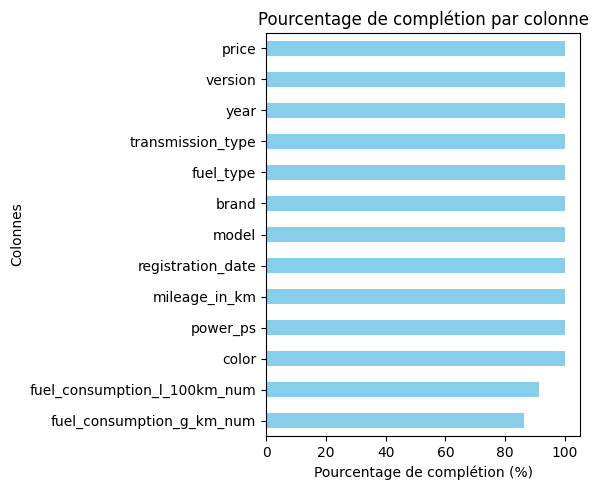

In [43]:
def plot_completion_percentage(df):
    # Calcul du pourcentage de complétion par colonne
    completion_percentage = df.notnull().mean() * 100

    # Créer un graphique
    plt.figure(figsize=(6, 5))
    completion_percentage.sort_values().plot(kind="barh", color="skyblue")

    # Ajouter des labels et un titre
    plt.xlabel("Pourcentage de complétion (%)")
    plt.ylabel("Colonnes")
    plt.title("Pourcentage de complétion par colonne")

    # Afficher le graphique
    plt.tight_layout()
    plt.show()


plot_completion_percentage(raw)


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.6.3 - Récupération du mois</h4>
</div>

In [44]:
raw["registration_date"] = pd.to_datetime(
    raw["registration_date"], format="%m/%Y", errors="coerce"
)

raw["month"] = raw["registration_date"].dt.month

In [45]:
df = raw.dropna().copy()

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 209496 entries, 0 to 250830
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   brand                         209496 non-null  str           
 1   model                         209496 non-null  str           
 2   color                         209496 non-null  str           
 3   registration_date             209496 non-null  datetime64[us]
 4   year                          209496 non-null  int64         
 5   power_ps                      209496 non-null  float64       
 6   transmission_type             209496 non-null  str           
 7   fuel_type                     209496 non-null  str           
 8   mileage_in_km                 209496 non-null  float64       
 9   version                       209496 non-null  str           
 10  price                         209496 non-null  float64       
 11  fuel_consumption_g_km_num    

<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;width: 90%; " >
<h2 style="margin: auto; padding: 20px; color:#fff; ">3 - Exploration - Analyse</h2>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">3.1 - Univarié</h3>
</div>

In [47]:
import plotly.io as pio

# Sélectionner selon le cas

# pio.renderers.default = (
#     "iframe"  # Option pour que cela s'affiche correctement sous Jupyter
# )

pio.renderers.default = "vscode"

# Pour Visual Studio Code, il faut écrire "plotly_mimetype" ou "vscode"
# Pour Jupyter, il faut écrire iframe

<div style="
    background-color: #439cc8; 
    color: #FFF; 
    font-size: 16px; 
    font-style: italic; 
    border-left: 6px solid #439CC8; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 5px;">
    ❗ La commande précédente permet d'afficher correctement les graphiques Plotly-Express qui peuvent ne pas s'afficher si la configuration est incorrecte.
</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.1.1 - Boxplot des prix</h4>
</div>

In [48]:
# Créer le boxplot horizontal avec échelle logarithmique
fig = px.box(
    df, 
    x="price", 
    title="Boxplot des prix (échelle logarithmique)", 
    log_x=True
)

# Afficher le graphique
fig.show()


<div style="
    background-color: #439cc8; 
    color: #FFF; 
    font-size: 16px; 
    font-style: italic; 
    border-left: 6px solid #439CC8; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 5px;">
    ✔ Les prix vont de 149 à 5 890 500 euros. Nous briderons notre échantillon à 1.5*IQR+Q3 soit 56222 euros max.
</div>

In [49]:
df = df[df['price']<=56222].copy()


In [50]:
df.query("price==149")

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
168419,renault,Renault Espace,grey,2004-01-01,2004,120.0,Manual,Diesel,237500.0,"Expression IV Motorschaden, Teile ausgebaut",149.0,187.0,7.0,1


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.1.2 - Boxplot des années</h4>
</div>

In [51]:
fig = px.box(df, x="year", title="Boxplot des year", log_x=False)

# Afficher le graphique
fig.show()


<div style="
    background-color: #439cc8; 
    color: #FFF; 
    font-size: 16px; 
    font-style: italic; 
    border-left: 6px solid #439CC8; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 5px;">
    ❌ Les années antérieures à 2005 sont considérées comme des outliers.
</div>

In [52]:
df.shape

(196291, 14)

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">3.2 - Bivarié</h3>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Code pour visualiser et analyser les liens bivariés
</div>

In [53]:
def analyze_data(df, num_var, cat_var):
    # 1. Nettoyage local : exclusion des valeurs nulles
    clean_df = df.dropna(subset=[num_var, cat_var])

    # 2. Boxplot Seaborn / Matplotlib
    plt.figure(figsize=(12, 4))
    sns.boxplot(y=cat_var, x=num_var, data=clean_df, orient="h")
    plt.xscale("log")  # Échelle log sur l'axe X
    plt.title(f"Box Plot de {num_var} par {cat_var} (échelle log)\n")
    plt.show()

    # 3. Test d'Anderson-Darling (normalité)
    result = anderson(clean_df[num_var])
    print("--- Résultats du test d'Anderson-Darling ---")
    print("Statistique :", result.statistic)
    print("Valeurs critiques :", result.critical_values)
    print("Niveaux de signification :", result.significance_level)

    # Extraction des groupes pour les tests statistiques
    groups = [
        group[num_var].values 
        for _, group in clean_df.groupby(cat_var)
    ]

    # 4. Orientations statistiques selon le résultat
    if result.statistic > result.critical_values[2]:  # Seuil 5%
        print("\nDistribution non normale -> Test de Kruskal-Wallis.")
        stat, p_value = kruskal(*groups)
        print("--- Résultats Kruskal-Wallis ---")
        print("Statistique :", stat)
        print("P-value :", p_value)
    else:
        print("\nDistribution normale -> Test ANOVA.")
        f_stat, p_value = f_oneway(*groups)
        print("--- Résultats ANOVA ---")
        print("Statistique F :", f_stat)
        print("P-value :", p_value)

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.1 - Boxplots des prix selon les années</h4>
</div>

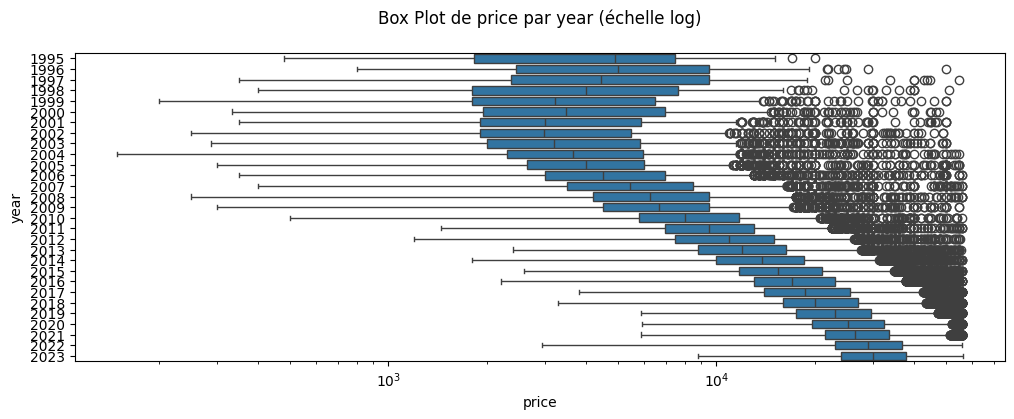

--- Résultats du test d'Anderson-Darling ---
Statistique : 1530.735389271431
Valeurs critiques : [0.561 0.631 0.752 0.873 1.035]
Niveaux de signification : [15.  10.   5.   2.5  1. ]

Distribution non normale -> Test de Kruskal-Wallis.
--- Résultats Kruskal-Wallis ---
Statistique : 103187.76486043836
P-value : 0.0


C:\Users\eric2\AppData\Local\Temp\ipykernel_14132\813306554.py:13: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = anderson(clean_df[num_var])


In [54]:
analyze_data(df, 'price', 'year')

<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    ❗ Suppression des années antérieures à 2005 où la variabilité a tendance à augmenter 
</div>

In [55]:
df = df[df['year']>=2005].copy()

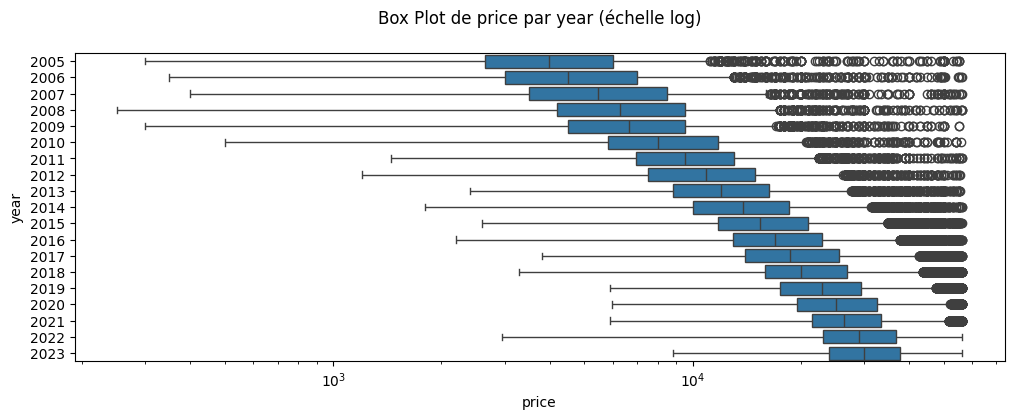

--- Résultats du test d'Anderson-Darling ---
Statistique : 1620.1137933206628
Valeurs critiques : [0.561 0.631 0.752 0.873 1.035]
Niveaux de signification : [15.  10.   5.   2.5  1. ]

Distribution non normale -> Test de Kruskal-Wallis.
--- Résultats Kruskal-Wallis ---
Statistique : 93484.40847066302
P-value : 0.0


C:\Users\eric2\AppData\Local\Temp\ipykernel_14132\813306554.py:13: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = anderson(clean_df[num_var])


In [56]:
analyze_data(df, 'price', 'year')

In [57]:
df.info()

<class 'pandas.DataFrame'>
Index: 189428 entries, 135 to 250830
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   brand                         189428 non-null  str           
 1   model                         189428 non-null  str           
 2   color                         189428 non-null  str           
 3   registration_date             189428 non-null  datetime64[us]
 4   year                          189428 non-null  int64         
 5   power_ps                      189428 non-null  float64       
 6   transmission_type             189428 non-null  str           
 7   fuel_type                     189428 non-null  str           
 8   mileage_in_km                 189428 non-null  float64       
 9   version                       189428 non-null  str           
 10  price                         189428 non-null  float64       
 11  fuel_consumption_g_km_num  

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.2 - Boxplots des prix selon le type de motorisation</h4>
</div>

In [58]:
df.fuel_type.value_counts()

fuel_type
Petrol           108050
Diesel            66151
Hybrid             9181
Electric           4913
LPG                 714
Diesel Hybrid       303
Other                66
CNG                  25
Unknown              22
Ethanol               3
Name: count, dtype: int64

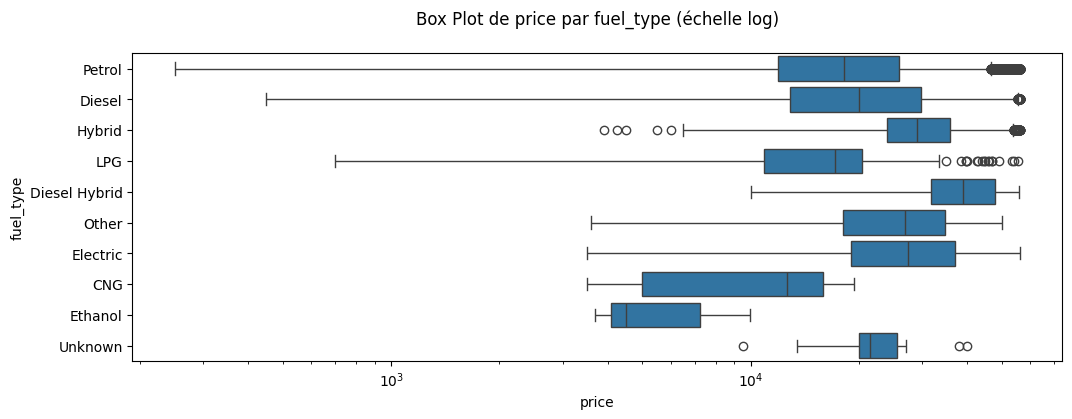

--- Résultats du test d'Anderson-Darling ---
Statistique : 1620.1137933206628
Valeurs critiques : [0.561 0.631 0.752 0.873 1.035]
Niveaux de signification : [15.  10.   5.   2.5  1. ]

Distribution non normale -> Test de Kruskal-Wallis.
--- Résultats Kruskal-Wallis ---
Statistique : 11173.109976262902
P-value : 0.0


C:\Users\eric2\AppData\Local\Temp\ipykernel_14132\813306554.py:13: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = anderson(clean_df[num_var])


In [59]:
analyze_data(df, 'price', 'fuel_type')

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>✔ Le type de motorisation joue sur le prix</p>
    <p>❌ Suppression des mentions anecdotiques inférieures à 100 </p>

</div>

In [60]:
# Calcul des effectifs de chaque groupe
fuel_counts = df["fuel_type"].value_counts()

# Sélection uniquement des types de carburant ayant au moins 100 occurrences
valid_fuel_types = fuel_counts[fuel_counts >= 100].index

# Filtrage du DataFrame
df = df[df["fuel_type"].isin(valid_fuel_types)]


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.3 - Boxplots des prix selon la couleur</h4>
</div>

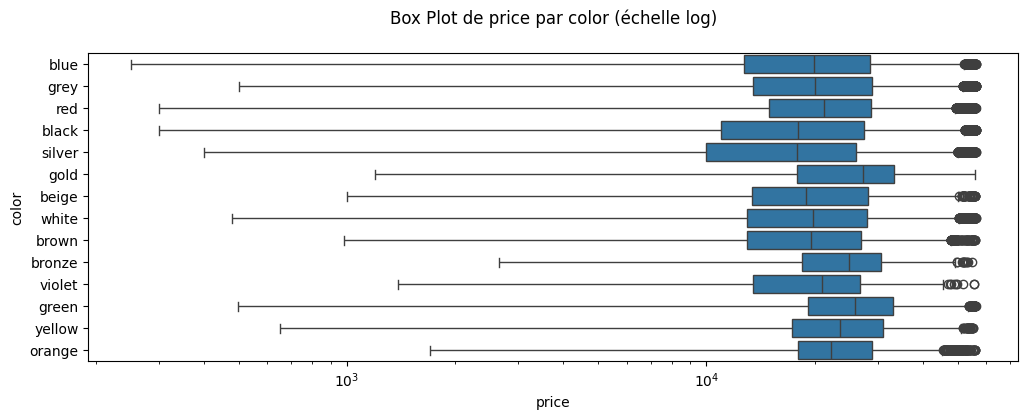

--- Résultats du test d'Anderson-Darling ---
Statistique : 1619.722004071984
Valeurs critiques : [0.561 0.631 0.752 0.873 1.035]
Niveaux de signification : [15.  10.   5.   2.5  1. ]

Distribution non normale -> Test de Kruskal-Wallis.
--- Résultats Kruskal-Wallis ---
Statistique : 2934.0915258636774
P-value : 0.0


C:\Users\eric2\AppData\Local\Temp\ipykernel_14132\813306554.py:13: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = anderson(clean_df[num_var])


In [61]:
analyze_data(df, 'price', 'color')

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>✔ La couleur joue sur le prix (P-value: 0.0)</p>
</div>

In [62]:
df.color.value_counts()

color
black     43205
grey      35894
white     31826
silver    24620
blue      23645
red       17152
brown      3510
orange     2820
green      2287
beige      1875
yellow     1319
gold        431
bronze      425
violet      303
Name: count, dtype: int64

In [63]:
df.head()

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
135,alfa-romeo,Alfa Romeo 147,blue,2005-10-01,2005,185.0,Manual,Petrol,126000.0,Brera,10599.0,287.0,12.1,10
136,alfa-romeo,Alfa Romeo Spider,blue,2005-06-01,2005,166.0,Manual,Petrol,203997.0,2.0 JTS Edizione 2005,5900.0,220.0,9.2,6
137,alfa-romeo,Alfa Romeo GT,grey,2005-06-01,2005,241.0,Manual,Petrol,143800.0,"3.2 V6 24V Distinctive Alfa-Scheckheft,1.Hand",17980.0,295.0,12.4,6
139,alfa-romeo,Alfa Romeo GT,grey,2005-09-01,2005,166.0,Manual,Petrol,219000.0,2.0 16V JTS Distinctive Leder Bose LM ATM,2000.0,207.0,8.7,9
140,alfa-romeo,Alfa Romeo GT,grey,2005-10-01,2005,241.0,Manual,Petrol,130260.0,"3.2 V6 24V Distinctive, LEDER, aAC, TEMPO,PDC",7990.0,295.0,12.4,10


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.4 - Boxplots des prix selon la transmission</h4>
</div>

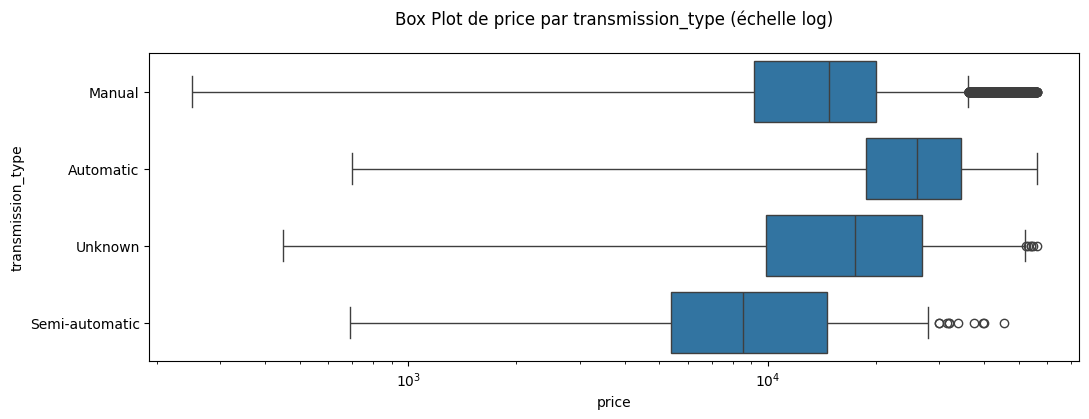

--- Résultats du test d'Anderson-Darling ---
Statistique : 1619.722004071984
Valeurs critiques : [0.561 0.631 0.752 0.873 1.035]
Niveaux de signification : [15.  10.   5.   2.5  1. ]

Distribution non normale -> Test de Kruskal-Wallis.
--- Résultats Kruskal-Wallis ---
Statistique : 49297.27284380534
P-value : 0.0


C:\Users\eric2\AppData\Local\Temp\ipykernel_14132\813306554.py:13: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = anderson(clean_df[num_var])


In [64]:
analyze_data(df, 'price', 'transmission_type')

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>✔ Le type de transmission joue sur le prix (P-value: 0.0)</p>
</div>

In [65]:
df.transmission_type.value_counts()

transmission_type
Automatic         95517
Manual            92880
Unknown             731
Semi-automatic      184
Name: count, dtype: int64

In [66]:
df.query("transmission_type=='Unknown'").head()

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
362,alfa-romeo,Alfa Romeo MiTo,black,2010-08-01,2010,95.0,Unknown,Petrol,193000.0,Turismo Zahnriemen neu Scheckheft gepflegt,3750.0,138.0,5.9,8
415,alfa-romeo,Alfa Romeo Giulietta,white,2011-02-01,2011,120.0,Unknown,Petrol,60000.0,Turismo (191),9500.0,156.0,6.6,2
526,alfa-romeo,Alfa Romeo MiTo,black,2015-12-01,2015,105.0,Unknown,Petrol,35000.0,Junior (11.2014-->) (145),11799.0,100.0,4.2,12
584,alfa-romeo,Alfa Romeo Giulia,grey,2017-05-01,2017,209.0,Unknown,Diesel,83961.0,2.2d Veloce Q4 1.Hand*84TKM*ACC*Memory*,24950.0,122.0,4.7,5
702,alfa-romeo,Alfa Romeo Stelvio,black,2018-06-01,2018,200.0,Unknown,Petrol,36500.0,2.0Turbo 16V - Ratenzahlung mgl.,33900.0,161.0,7.0,6


In [67]:
df.query("version=='2.2d Veloce Q4 1.Hand*84TKM*ACC*Memory*'")

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
584,alfa-romeo,Alfa Romeo Giulia,grey,2017-05-01,2017,209.0,Unknown,Diesel,83961.0,2.2d Veloce Q4 1.Hand*84TKM*ACC*Memory*,24950.0,122.0,4.7,5


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    ❌ Suppression des transmissions dont le type est inconnu
</div>

In [68]:
df = df[df["transmission_type"]!="Unknown"].copy()

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.5 - Matrice de corrélation</h4>
</div>

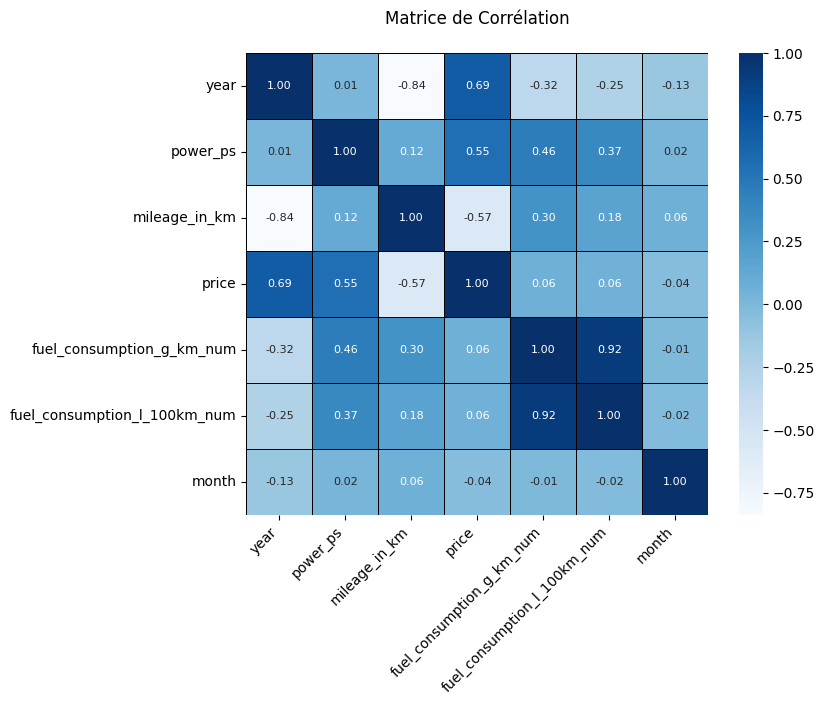

In [69]:
# Calcul de la matrice de corrélation en spécifiant numeric_only=True
correlation_matrix = df.corr(numeric_only=True, method="spearman")

plt.figure(figsize=(8, 6))
# Création d'une heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="black",
    annot_kws={"size": 8},
)

# Ajustement des étiquettes et du titre
plt.title("Matrice de Corrélation\n", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Affichage de la figure
plt.show()


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Commentaires sur les corrélations :</p>
    <p>❌ Liens trop forts entre fuel_consumption_g_km_num et fuel_consumption_l_100km_num</p>
    <p>✔ Lien très fort entre month et mileage_in_km</p>
    <p>✔ Corrélations assez fortes entre price et year et price et power_ps : un véhicule récent ou puissant est plus cher.</p>
</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.6 - Pairplot pour repérer les liens entre les variables</h4>
</div>

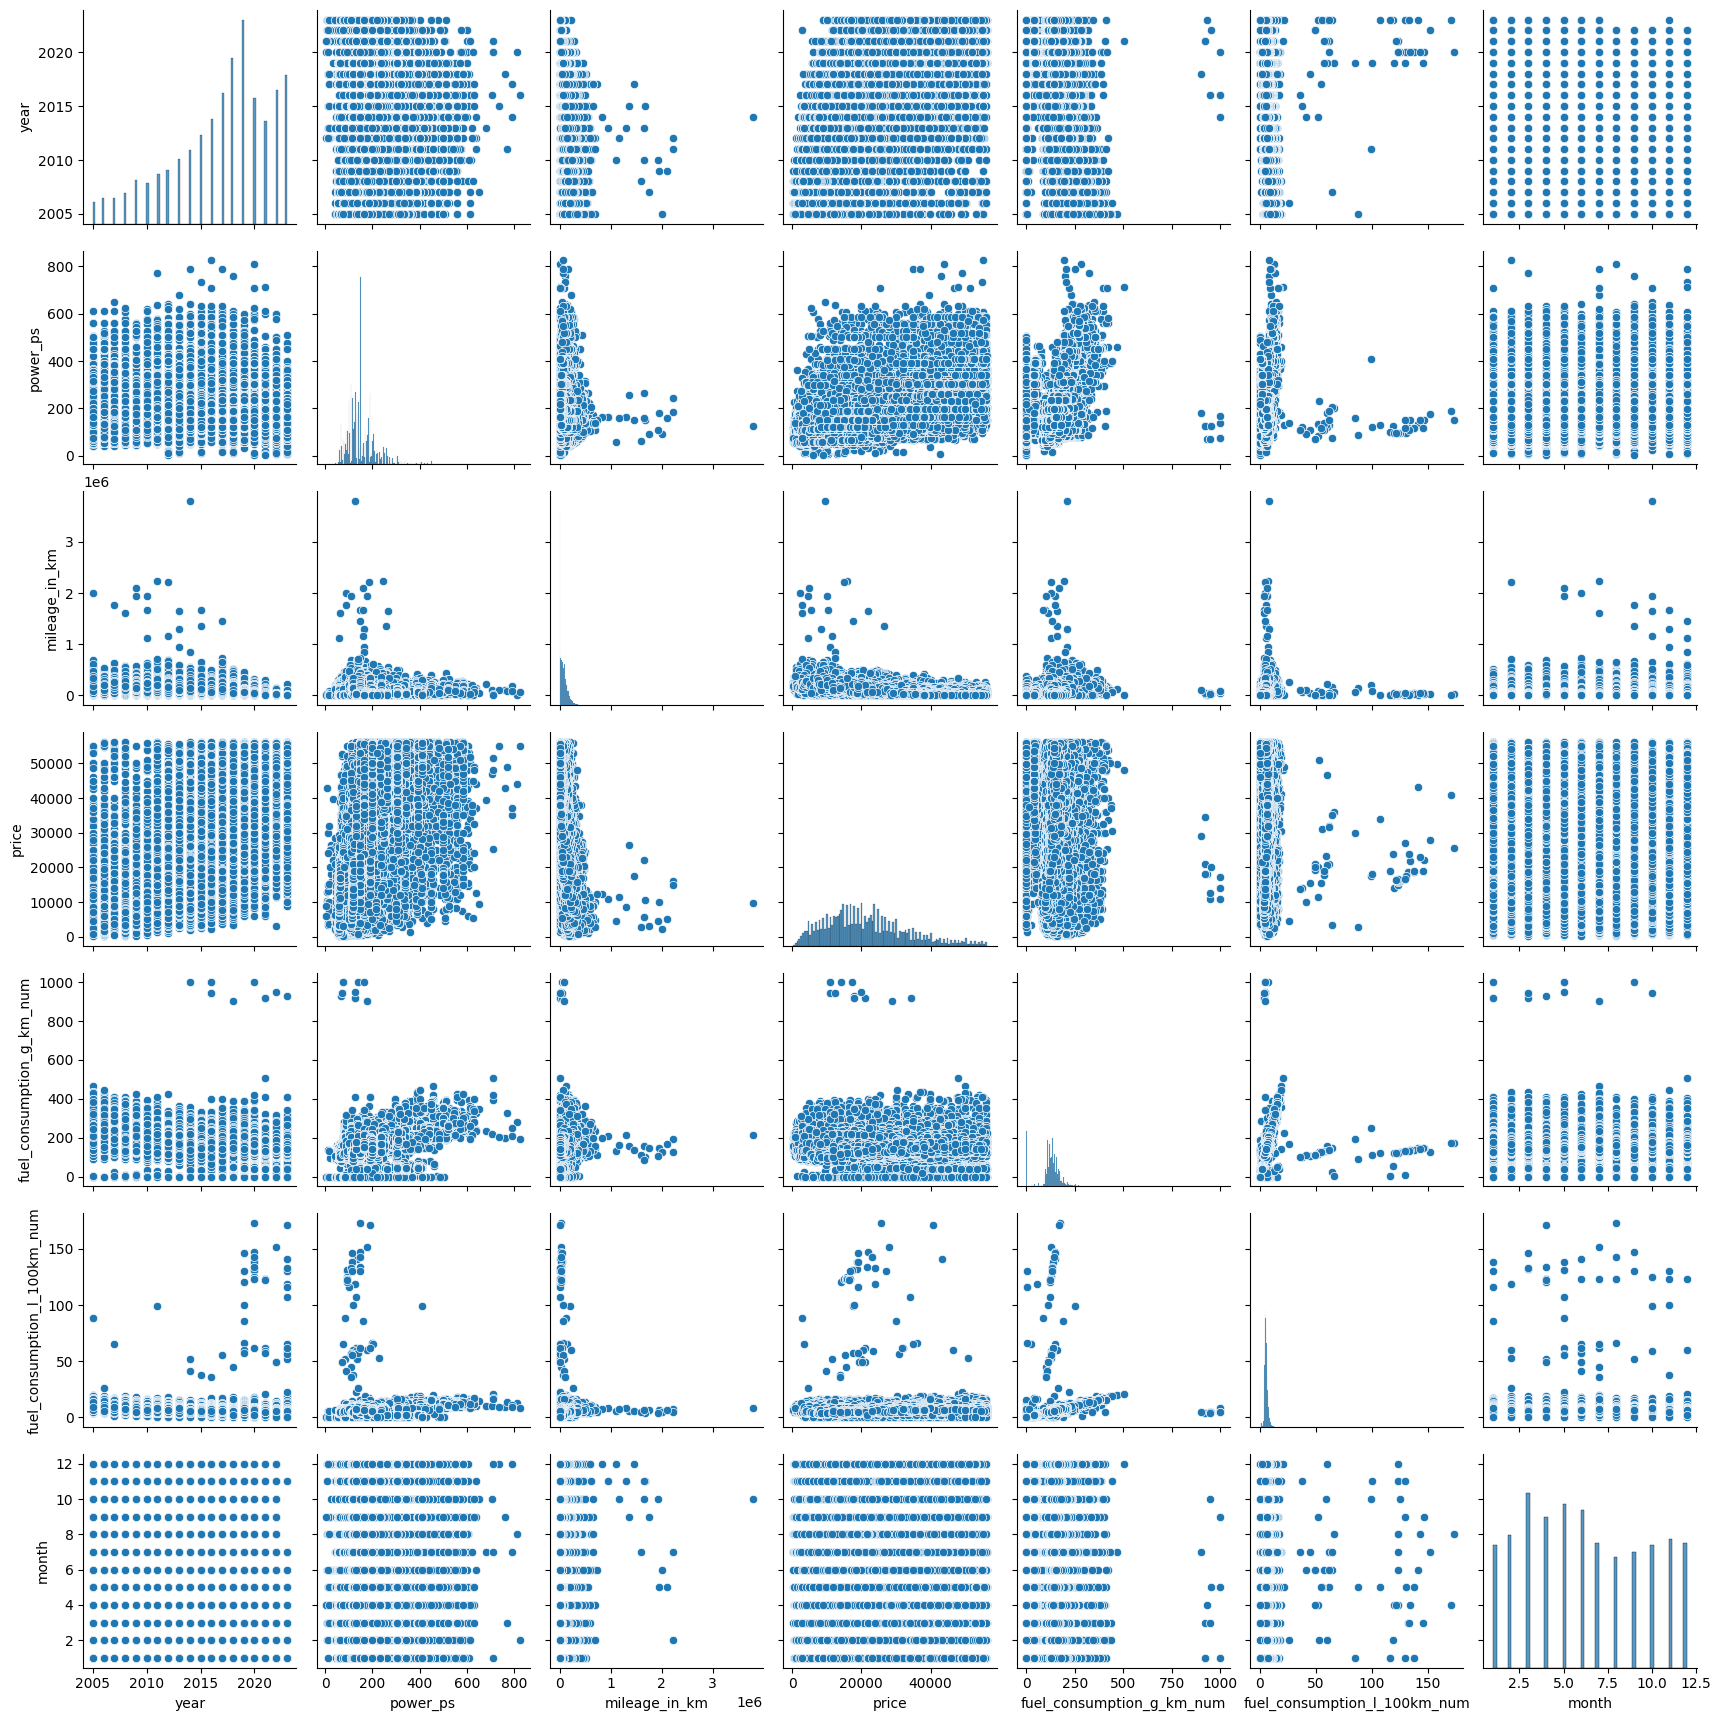

In [70]:
# Filtrer uniquement les colonnes numériques
df_numeric = df.select_dtypes(include=["number"]).copy()

# Générer le pairplot uniquement pour les colonnes numériques
sns.pairplot(df_numeric)

# Afficher le plot
plt.show()


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>❌ Hormis pour les fuel_consumption, pas de liens linéaires ou autres entre les valeurs numériques.</p>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">3.3 - Multivarié</h3>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Une Analyse en Composantes Principales va être réalisée pour bien comprendre le fonctionnement des données.
</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.3.1 - Préparation des données</h4>
</div>

In [71]:
# Colonnes numériques
num_features = [
    "year",
    "price",
    "power_ps",
    "fuel_consumption_g_km_num",
    "mileage_in_km",
    "month",
]

# Colonnes catégorielles à binariser
cat_features = ["transmission_type", "fuel_type"]

# Copie du DataFrame en gardant les variables d'intérêt
df_price_std = df[num_features + cat_features].copy()

# Binarisation des variables catégorielles
df_price_std = pd.get_dummies(df_price_std, columns=cat_features, drop_first=True)

# Combinaison des colonnes numériques et binarisées
final_columns = num_features + [
    col for col in df_price_std.columns if col not in num_features
]

# Standardisation sur toutes les colonnes
scaler = StandardScaler()
df_price_std[final_columns] = scaler.fit_transform(df_price_std[final_columns])

# Afficher un aperçu des données
df_price_std.head()


,year,price,power_ps,fuel_consumption_g_km_num,mileage_in_km,month,transmission_type_Manual,transmission_type_Semi-automatic,fuel_type_Diesel Hybrid,fuel_type_Electric,fuel_type_Hybrid,fuel_type_LPG,fuel_type_Petrol
135,-2.629197,-0.922395,0.436069,3.408130,0.621094,1.100374,1.015073,-0.031252,-0.040116,-0.162455,-0.22591,-0.061605,0.866547
136,-2.629197,-1.327051,0.157155,1.908476,1.683861,-0.080537,1.015073,-0.031252,-0.040116,-0.162455,-0.22591,-0.061605,0.866547
137,-2.629197,-0.286779,1.258131,3.587193,0.863632,-0.080537,1.015073,-0.031252,-0.040116,-0.162455,-0.22591,-0.061605,0.866547
139,-2.629197,-1.662900,0.157155,1.617499,1.888288,0.805146,1.015073,-0.031252,-0.040116,-0.162455,-0.22591,-0.061605,0.866547
140,-2.629197,-1.147070,1.258131,3.587193,0.679140,1.100374,1.015073,-0.031252,-0.040116,-0.162455,-0.22591,-0.061605,0.866547


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Les variables numériques sont standardisées et les variables catégorielles binarisées.</p>
    <p>La standardisation met toutes les variables numériques sur la même ligne de départ, en évitant que les variables qui varient le plus écrasent les autres.</p>
    <p>La binarisation permet d'intégrer les variables catégorielles dans l'ACP.</p>
</div>

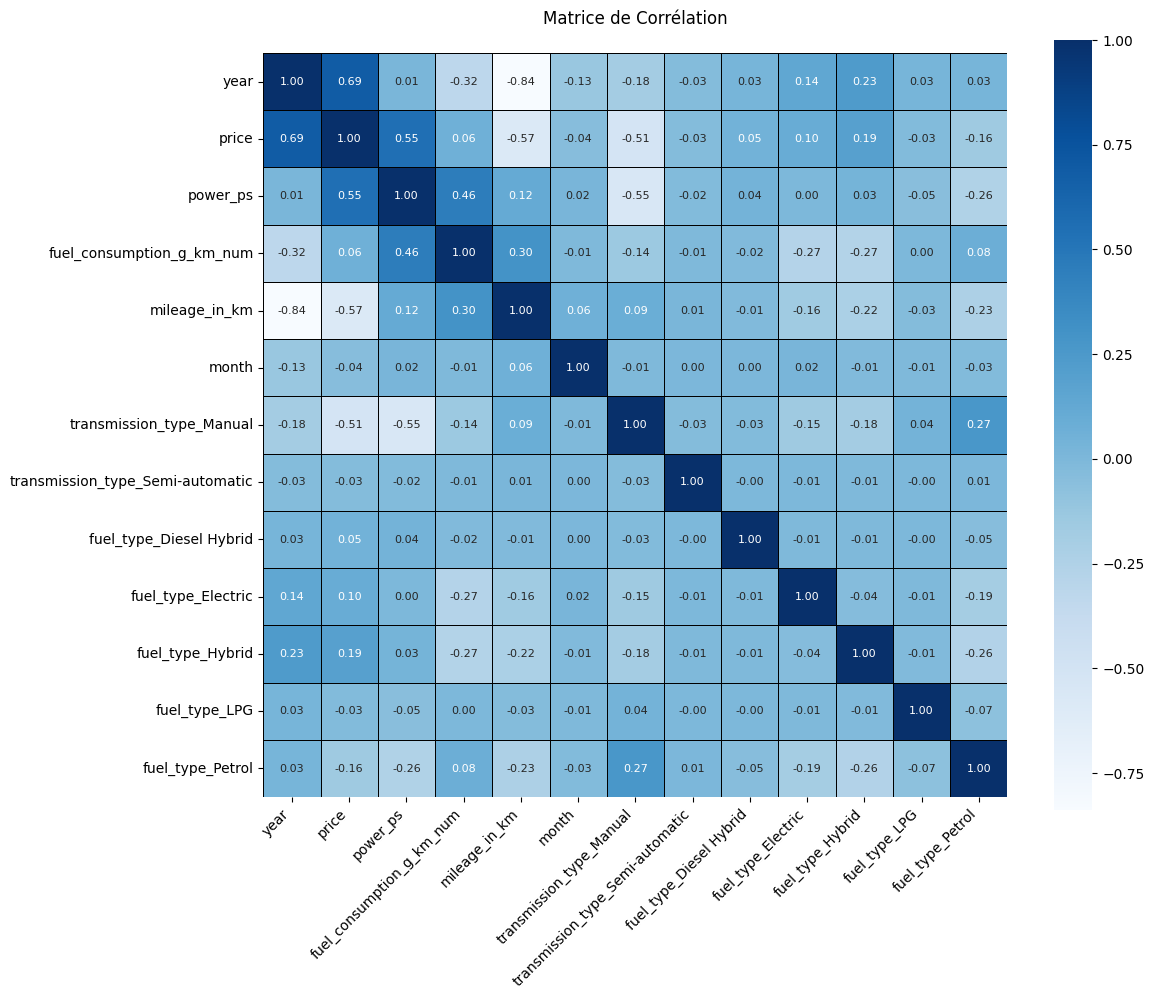

In [72]:
correlation_matrix = df_price_std.corr(numeric_only=True, method="spearman")

plt.figure(figsize=(12, 10))
# Création d'une heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="black",
    annot_kws={"size": 8},
)

# Ajustement des étiquettes et du titre
plt.title("Matrice de Corrélation\n", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Affichage de la figure
plt.show()


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>✔ Pas de corrélation trop élevée (supérieure à 0.9)</p>
    <p>❌ Les variables ne partageant aucune relation avec aucune des autres variables sont écartées.</p>
</div>

In [73]:
df_price_std.drop(
    [
        "month",
        "transmission_type_Semi-automatic",
        "fuel_type_Diesel Hybrid",
        "fuel_type_LPG",
    ],
    axis=1,
    inplace=True,
)


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.3.2 - Analyse en composantes principales (ACP)</h4>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Code pour tracer l'éboulis de valeurs propres.
</div>

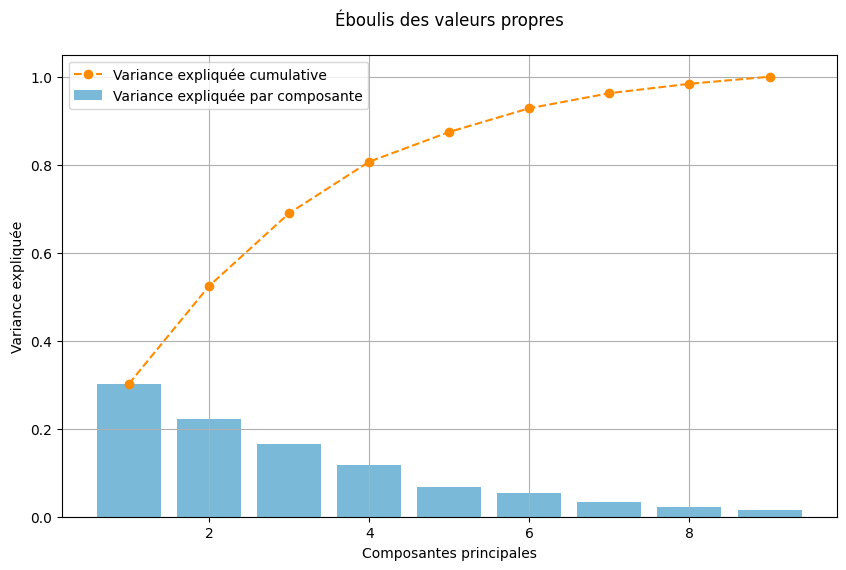

In [74]:
# Initialisation de l'ACP
pca = PCA()
pca.fit(df_price_std)


def scree_plot(pca, fig_size=(10, 6)):
    # Calcul de la variance expliquée et cumulée
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    # Déclaration du graphique
    plt.figure(figsize=fig_size)

    # Barres pour la variance expliquée de chaque composante
    plt.bar(
        range(1, len(explained_variance) + 1),
        explained_variance,
        alpha=0.7,
        align="center",
        label="Variance expliquée par composante",
        color="#439cc8",
    )

    # Courbe de la variance expliquée cumulative
    plt.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        marker="o",
        linestyle="--",
        color="darkorange",
        label="Variance expliquée cumulative",
    )

    plt.xlabel("Composantes principales")
    plt.ylabel("Variance expliquée")
    plt.title("Éboulis des valeurs propres\n")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()


# Lancement de la fonction
scree_plot(pca)


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>✔ Le seuil des 80% de variance expliquée est atteint pour 4 composantes.</p>
    <p>Nous étudierons donc les 4 premières composantes.</p>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Code pour dessiner le cercle des corrélations.
</div>

In [75]:
# Fonction pour juste dessiner le cercle
def draw_correlation_circle(ax):
    ax.add_artist(plt.Circle((0, 0), 1, color="#555", fill=False, linestyle="-"))


# Fonction pour dessiner le cercle des corrélations
def plot_correlation_circle(pca, components, feature_names):
    arrow_size = 0.05
    fig, ax = plt.subplots(figsize=(7, 7))
    draw_correlation_circle(ax)

    for i, feature in enumerate(feature_names):
        x, y = pca.components_[components, i]
        norm = np.linalg.norm([x, y])

        if norm != 0:
            x_base = x - x / norm * arrow_size
            y_base = y - y / norm * arrow_size
            ax.plot([0, x_base], [0, y_base], color="#439cc8")
            ax.quiver(
                x_base,
                y_base,
                x / norm * arrow_size,
                y / norm * arrow_size,
                angles="xy",
                scale_units="xy",
                scale=1,
                color="#439cc8",
            )

        ax.text(x * 1.05, y * 1.05, feature, color="black", ha="center", va="center")

    var_ratio = pca.explained_variance_ratio_[components] * 100

    x_label = f"\nComp. {components[0] + 1} ({var_ratio[0]:.2f}%)"
    y_label = f"Comp. {components[1] + 1} ({var_ratio[1]:.2f}%)"
    title = f"Cercle des corrélations\nVariance expliquée : {var_ratio.sum():.2f}%\n"

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid()
    ax.axhline(0, color="#555", linewidth=1)
    ax.axvline(0, color="#555", linewidth=1)
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_aspect("equal", adjustable="box")
    plt.show()


<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    1er plan factoriel
</div>

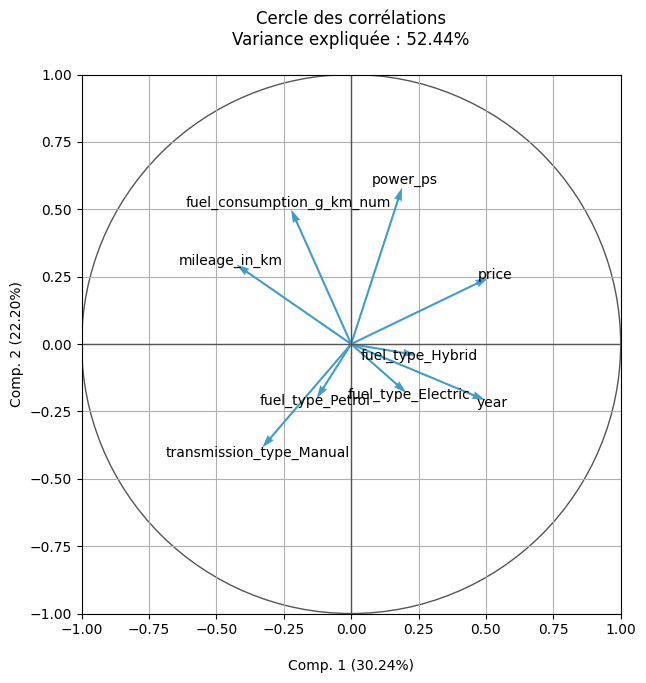

In [76]:
# Exemple sur composante 1 et 2 correspondants à [0,1]
plot_correlation_circle(pca, [0, 1], df_price_std.columns)

<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Analyse du premier plan factoriel</p>
    <p>Le prix, l'année et le kilométrage (mileage_in_km) sont les variables les plus importantes.</p>
    <p>1️⃣ Composante 1 marquée par l'opposition entre les prix et l'année d'une part et le kilométrage d'autre part : plus un véhicule est récent ou a peu de kilomètres, plus son prix est élevé.</p>
    <p>2️⃣ Composante 2 marquée par l'opposition entre la puissance, la consommation et le kilométrage d'une part et la transmission manuelle d'autre part : plus une voiture est puissante, plus elle consomme, plus elle a de kilomètres et mais moins elle est de type boîte manuelle.</p>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    2ème plan factoriel
</div>

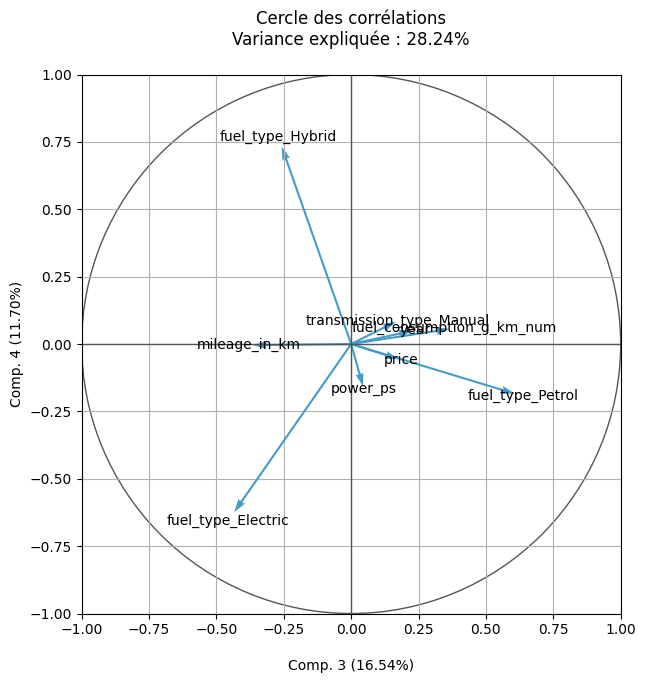

In [77]:
plot_correlation_circle(pca, [2,3], df_price_std.columns)

<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Analyse du deuxième plan factoriel</p>
    <p>Le prix, l'année et le kilométrage (mileage_in_km) sont les variables les plus importantes.</p>
    <p>3️⃣ Composante 3 marquée par l'opposition entre les voitures essence et les voitures électriques.</p>
    <p>4️⃣ Composante 4 marquée par l'opposition entre les voitures hybrides et électriques.</p>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Coefficients de charge
</div>

In [78]:
# Calcul des coefficients de charge
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Mise sous forme de DataFrame
loadings_df = pd.DataFrame(
    loadings,
    columns=[f"Composante {i + 1}" for i in range(pca.n_components_)],
    index=df_price_std.columns,
)

# Affichage avec mise en forme
display(loadings_df.style.background_gradient(cmap="Blues"))


,Composante 1,Composante 2,Composante 3,Composante 4,Composante 5,Composante 6,Composante 7,Composante 8,Composante 9
year,0.821036,-0.294002,0.274948,0.049633,-0.241808,-0.058347,-0.108637,0.230852,-0.185573
price,0.841090,0.346934,0.214849,-0.057573,-0.160329,0.111206,-0.026196,0.055214,0.284478
power_ps,0.311336,0.820376,0.053751,-0.161746,0.128524,0.327680,-0.207097,-0.117963,-0.142515
fuel_consumption_g_km_num,-0.367456,0.706042,0.445852,0.057439,-0.087695,0.050525,0.365596,0.131515,-0.056602
mileage_in_km,-0.702982,0.416844,-0.443196,-0.004350,-0.021025,-0.009590,-0.235028,0.277411,0.053784
transmission_type_Manual,-0.544515,-0.543470,0.202528,0.085306,-0.295138,0.520956,-0.031341,0.001678,0.019159
fuel_type_Electric,0.338079,-0.256464,-0.529488,-0.640227,0.169073,0.210785,0.210366,0.109916,-0.018282
fuel_type_Hybrid,0.397887,-0.057822,-0.314290,0.751353,0.345357,0.205764,0.088585,0.074686,0.001698
fuel_type_Petrol,-0.211383,-0.285872,0.740700,-0.189343,0.515245,0.025015,-0.101202,0.103483,0.045376


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Les coefficients de charge renvoient les mêmes informations que les cercles des corrélations mais permettent d'embrasser l'importance des variables sur chaque composante offrant ainsi une vision plus globale.</p>
</div>

<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;width: 90%; " >
<h2 style="margin: auto; padding: 20px; color:#fff; ">4 - Export des données</h2>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">4.1 - Conversion des types</h3>
</div>

In [79]:
# Conversion des types des colonnes dans le DataFrame df
df = df.astype(
    {
        "year": "int16",  # Années (1995-2023)
        "power_ps": "int16",  # Puissance en PS (5-825)
        "mileage_in_km": "int32",  # Kilométrage en km (0-3,800,000)
        "price": "int32",  # Prix (149-56,222)
        "fuel_consumption_g_km_num": "float32",  # Consommation en g/km (0-999)
        "fuel_consumption_l_100km_num": "float32",  # Consommation en l/100km (0-173)
        "month": "int8",  # Mois (1-12)
    }
)


In [80]:
df.info()

<class 'pandas.DataFrame'>
Index: 188581 entries, 135 to 250830
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   brand                         188581 non-null  str           
 1   model                         188581 non-null  str           
 2   color                         188581 non-null  str           
 3   registration_date             188581 non-null  datetime64[us]
 4   year                          188581 non-null  int16         
 5   power_ps                      188581 non-null  int16         
 6   transmission_type             188581 non-null  str           
 7   fuel_type                     188581 non-null  str           
 8   mileage_in_km                 188581 non-null  int32         
 9   version                       188581 non-null  str           
 10  price                         188581 non-null  int32         
 11  fuel_consumption_g_km_num  

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">4.2 - Export</h3>
</div>

In [81]:
# Enregistrer le DataFrame en format Parquet
fic = os.path.join(my_path,"data/processed/data_clean.parquet")
df.to_parquet(fic, engine="pyarrow", index=False)

<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Après une mise en forme des types, les données sont exportées dans un format comme parquet conservant les types des variables.</p>
</div>